In [221]:
##import libraries

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

# set visualization theme
sns.set()

In [222]:
## Import the dataset

df = pd.read_csv('/Users/xlade/Desktop/Amdari/Internship/Jewelry Price Optimization/Jewelry_Dataset.csv')

In [223]:
# peek at the dataset
df.head(5)



,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1806829201890738522,jewelry.earring,0,561.51,1515915625207851155,Unnamed: 9,red,gold,diamond
0,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN


In [224]:
## Assign column names to the dataset

df.columns = [
    "Order_Datetime",
    "Order_ID",
    "Product_ID",
    'SKU_Quantity',
    'Category_ID',
    'Category',
    'Brand_ID',
    "Price_USD",
    "User_ID",
    "Target_Gender",
    "Main_Color", 
    "Main_metal",
    "Main_Gem"
]

In [225]:
# peek at the dataset again
df.head(5)


,Order_Datetime,Order_ID,Product_ID,SKU_Quantity,Category_ID,Category,Brand_ID,Price_USD,User_ID,Target_Gender,Main_Color,Main_metal,Main_Gem
0,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN


In [226]:
## check for missing values 

df.isnull().sum()

Order_Datetime        0
Order_ID              0
Product_ID            0
SKU_Quantity          0
Category_ID        5352
Category           9933
Brand_ID           4785
Price_USD          5352
User_ID            5352
Target_Gender     48167
Main_Color         7660
Main_metal         5462
Main_Gem          34058
dtype: int64

In [227]:
## see how much entries we have
df.shape

(95910, 13)

In [228]:
## feature cardinality
df.nunique()

Order_Datetime    74504
Order_ID          74759
Product_ID         9613
SKU_Quantity          1
Category_ID          25
Category            218
Brand_ID           2537
Price_USD          3166
User_ID           31079
Target_Gender         2
Main_Color            5
Main_metal            3
Main_Gem             30
dtype: int64

In [229]:
## Data description
df.describe()

,Order_ID,Product_ID,SKU_Quantity,Category_ID,Brand_ID,Price_USD,User_ID
count,9.591000e+04,9.591000e+04,95910.0,9.055800e+04,9.112500e+04,90558.000000,9.055800e+04
mean,2.485191e+18,1.815970e+18,1.0,1.805947e+18,8.891036e+16,362.213017,1.512644e+18
std,1.934750e+17,2.136814e+17,0.0,2.083954e+16,3.559651e+17,444.157665,2.374776e+16
min,1.924899e+18,1.313551e+18,1.0,1.313678e+18,0.000000e+00,0.990000,1.313554e+18
25%,2.379732e+18,1.515966e+18,1.0,1.806829e+18,0.000000e+00,145.620000,1.515916e+18
50%,2.524282e+18,1.956664e+18,1.0,1.806829e+18,1.000000e+00,258.770000,1.515916e+18
75%,2.644347e+18,1.956664e+18,1.0,1.806829e+18,1.000000e+00,431.370000,1.515916e+18
max,2.719022e+18,2.541962e+18,1.0,1.806829e+18,1.550613e+18,34448.600000,1.554297e+18


In [230]:
##more info on the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95910 entries, 0 to 95909
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_Datetime  95910 non-null  object 
 1   Order_ID        95910 non-null  int64  
 2   Product_ID      95910 non-null  int64  
 3   SKU_Quantity    95910 non-null  int64  
 4   Category_ID     90558 non-null  float64
 5   Category        85977 non-null  object 
 6   Brand_ID        91125 non-null  float64
 7   Price_USD       90558 non-null  float64
 8   User_ID         90558 non-null  float64
 9   Target_Gender   47743 non-null  object 
 10  Main_Color      88250 non-null  object 
 11  Main_metal      90448 non-null  object 
 12  Main_Gem        61852 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 9.5+ MB


In [231]:
## Check for duplicate values 

num_duplicated = len(df.loc[df.duplicated()])
print(f"Numbers of duplicated records:", num_duplicated)

Numbers of duplicated records: 2589


In [232]:
## feature with the cardinality of 1 (invariant features)
invariant_features = df.nunique()[df.nunique() == 1].index.tolist()
invariant_features


['SKU_Quantity']

In [233]:
## check for label distribution
df["Price_USD"].skew()

18.95906072625981

In [234]:
## price Kurtosis
df["Price_USD"].kurtosis()

1054.8979068506155

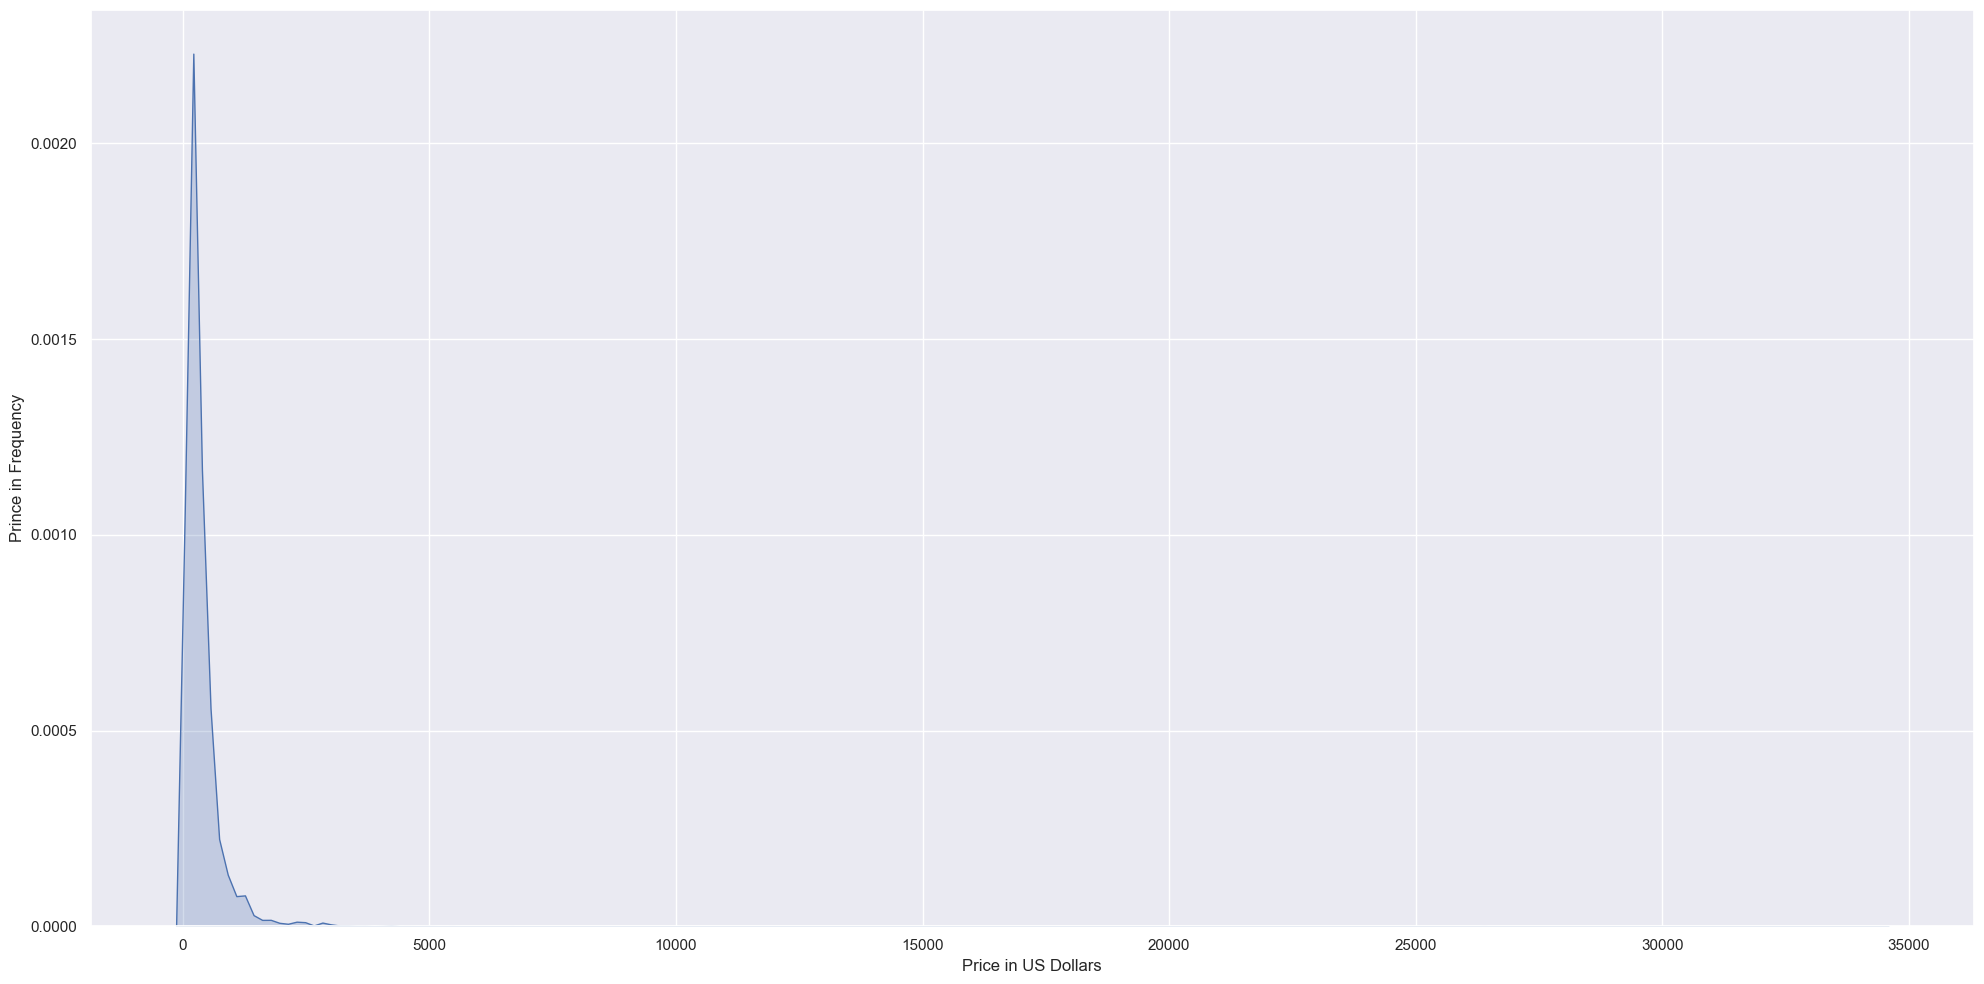

In [235]:
## Visualize price distribution

plt.figure( figsize = (20, 10))

sns.kdeplot(data = df, x = "Price_USD", fill = True, bw_adjust = 1)

plt.xlabel("Price in US Dollars")
plt.ylabel("Prince in Frequency")

plt.tight_layout()
plt.show(); plt.close()

In [236]:
## Target gender analysis
df["Target_Gender"].value_counts()

Target_Gender
f    47379
m      364
Name: count, dtype: int64

In [237]:
## Target gender analysis
df["Target_Gender"].value_counts(normalize = True)

Target_Gender
f    0.992376
m    0.007624
Name: proportion, dtype: float64

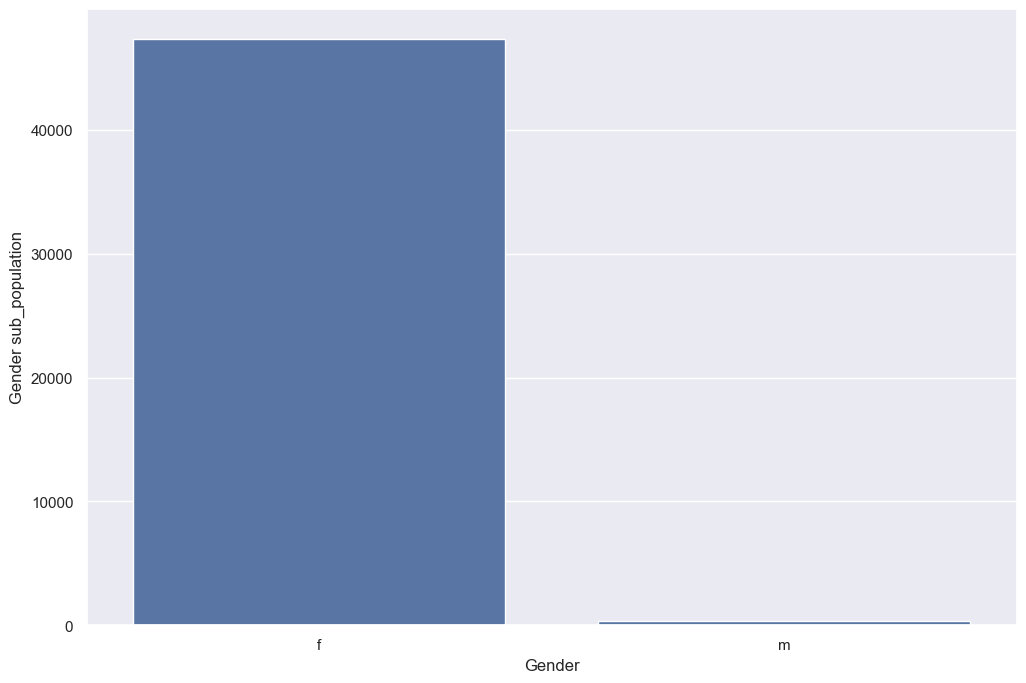

In [238]:
## visualize the target gender
plt.figure(figsize = (12, 8))

sns.countplot(data=df, x = "Target_Gender")

plt.xlabel("Gender")
plt.ylabel("Gender sub_population")

plt.show(); plt.close()


In [239]:
## jewelry category analysis
df["Category"].value_counts()

Category
jewelry.earring     29051
jewelry.ring        28300
jewelry.pendant     13088
jewelry.bracelet     6188
0.00                 4392
                    ...  
626.58                  1
13.42                   1
2.88                    1
101.23                  1
253.77                  1
Name: count, Length: 218, dtype: int64

In [240]:
df["Category"].unique()

array([nan, 'jewelry.pendant', 'jewelry.necklace', 'jewelry.earring',
       'jewelry.ring', 'jewelry.brooch', 'jewelry.bracelet',
       'electronics.clocks', 'jewelry.souvenir', '230.12', '202.36',
       '1098.03', '321.78', '1128.62', '81.27', '34.25', '582.16',
       '227.37', '234.22', '150.55', '131.82', '2123.15', '109.45',
       '49.22', '472.47', '205.38', '2746.44', '51.08', '231.12', '76.97',
       '3054.73', '184.90', '380.10', '357.49', '15.47', '135.33',
       '719.75', '93.01', '177.95', 'jewelry.stud', '102.10', '595.75',
       '469.56', '427.07', '53.62', '77.53', '1469.18', '355.27',
       '184.89', '154.66', '300.58', '83.73', '271.19', '3294.21',
       '278.04', '3626.26', '126.03', '283.52', '114.38', '89.04', '8.22',
       '124.88', '89.73', '171.23', '136.93', '19.04', '158.77', '187.10',
       '151.92', '1845.89', '87.23', '248.58', '596.48', '208.88',
       '193.11', '169.84', '1447.68', '45.07', '136.85', '282.05',
       '61.51', '210.21', '137.12'

In [241]:


categories = df["Category"].unique().tolist()
categories = [c for c in categories if isinstance(c, str) and "jewelry" in c ]
categories

['jewelry.pendant',
 'jewelry.necklace',
 'jewelry.earring',
 'jewelry.ring',
 'jewelry.brooch',
 'jewelry.bracelet',
 'jewelry.souvenir',
 'jewelry.stud']

In [242]:
## Pick out authentic data in categories 
real_categories =df.loc[df["Category"].isin(categories)]
real_categories

,Order_Datetime,Order_ID,Product_ID,SKU_Quantity,Category_ID,Category,Brand_ID,Price_USD,User_ID,Target_Gender,Main_Color,Main_metal,Main_Gem
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN
5,2018-12-02 22:09:34 UTC,1925760595336888995,1600021442638905547,1,1.806829e+18,jewelry.earring,0.0,150.55,1.515916e+18,NaN,red,gold,diamond
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95900,2021-12-01 09:32:35 UTC,2719009022110859402,1956663836207481431,1,1.806829e+18,jewelry.ring,0.0,145.62,1.515916e+18,NaN,red,gold,NaN
95903,2021-12-01 09:37:28 UTC,2719011482355368159,1956663847389495299,1,1.806829e+18,jewelry.earring,0.0,301.23,1.515916e+18,NaN,red,gold,amethyst
95907,2021-12-01 09:52:06 UTC,2719018846999544322,1956663848219968336,1,1.806829e+18,jewelry.earring,1.0,630.00,1.515916e+18,f,white,gold,diamond
95908,2021-12-01 09:55:35 UTC,2719020596963836492,1835566854106513435,1,1.806829e+18,jewelry.earring,0.0,83.42,1.515916e+18,NaN,white,gold,fianit


In [243]:
## percentage of missing data
100 * df.isnull().sum() / len(df)

Order_Datetime     0.000000
Order_ID           0.000000
Product_ID         0.000000
SKU_Quantity       0.000000
Category_ID        5.580231
Category          10.356584
Brand_ID           4.989052
Price_USD          5.580231
User_ID            5.580231
Target_Gender     50.221041
Main_Color         7.986654
Main_metal         5.694922
Main_Gem          35.510374
dtype: float64

In [244]:
## percentage of missing values in real categories
100 * real_categories.isnull().sum() / len(df)

Order_Datetime     0.000000
Order_ID           0.000000
Product_ID         0.000000
SKU_Quantity       0.000000
Category_ID        0.000000
Category           0.000000
Brand_ID           3.614847
Price_USD          0.000000
User_ID            0.000000
Target_Gender     37.617558
Main_Color         2.228131
Main_metal         0.092795
Main_Gem          20.328433
dtype: float64

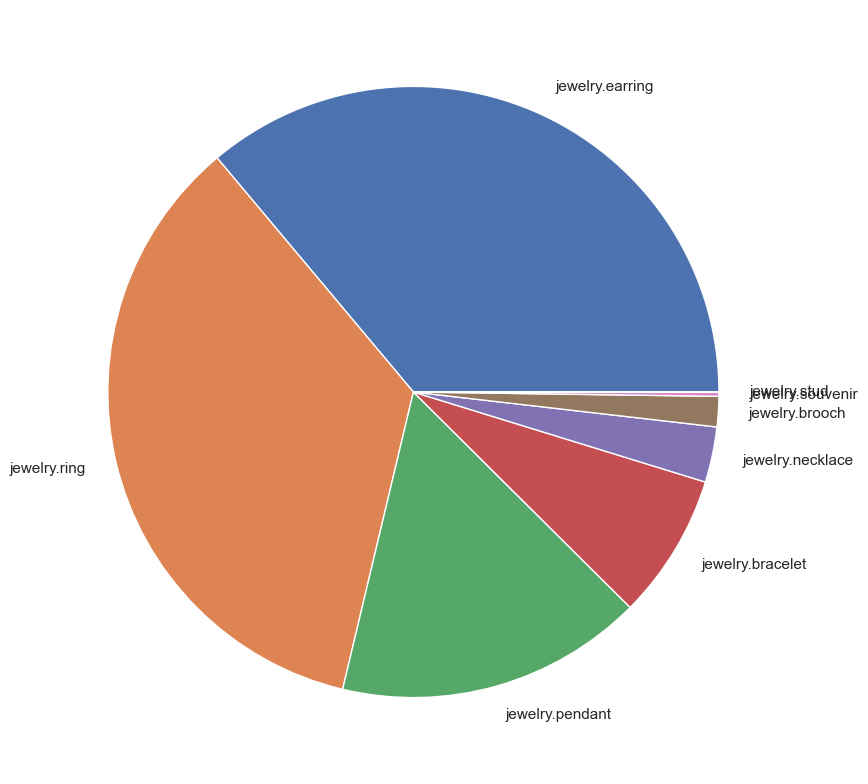

In [245]:
## visualize our categories
subdata = real_categories["Category"].value_counts()

jewelry_categories, counts = subdata.index.tolist(), subdata.values.tolist()

plt.figure(figsize = (12, 8))

plt.pie(x = counts, labels = jewelry_categories)

plt.tight_layout()
plt.show()

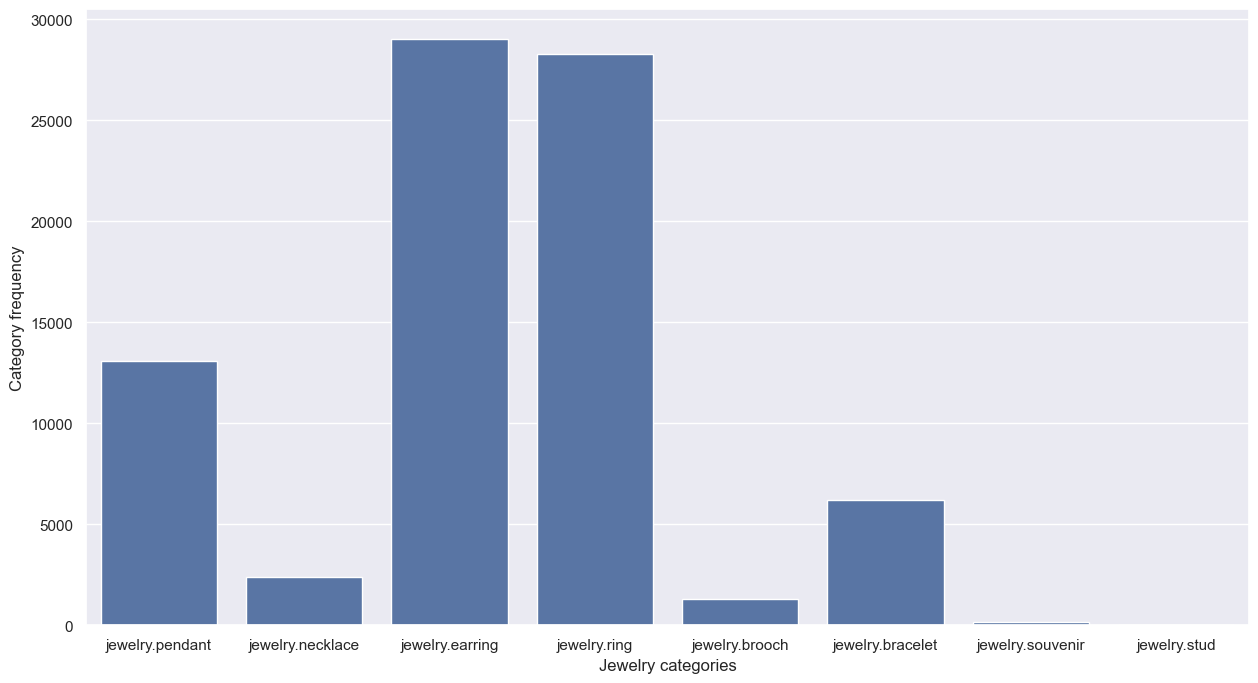

In [246]:
## category count plot

plt.figure(figsize = (15, 8))

sns.countplot(data = real_categories, x = "Category")

plt.xlabel("Jewelry categories")
plt.ylabel("Category frequency")

plt.show(); plt.close()

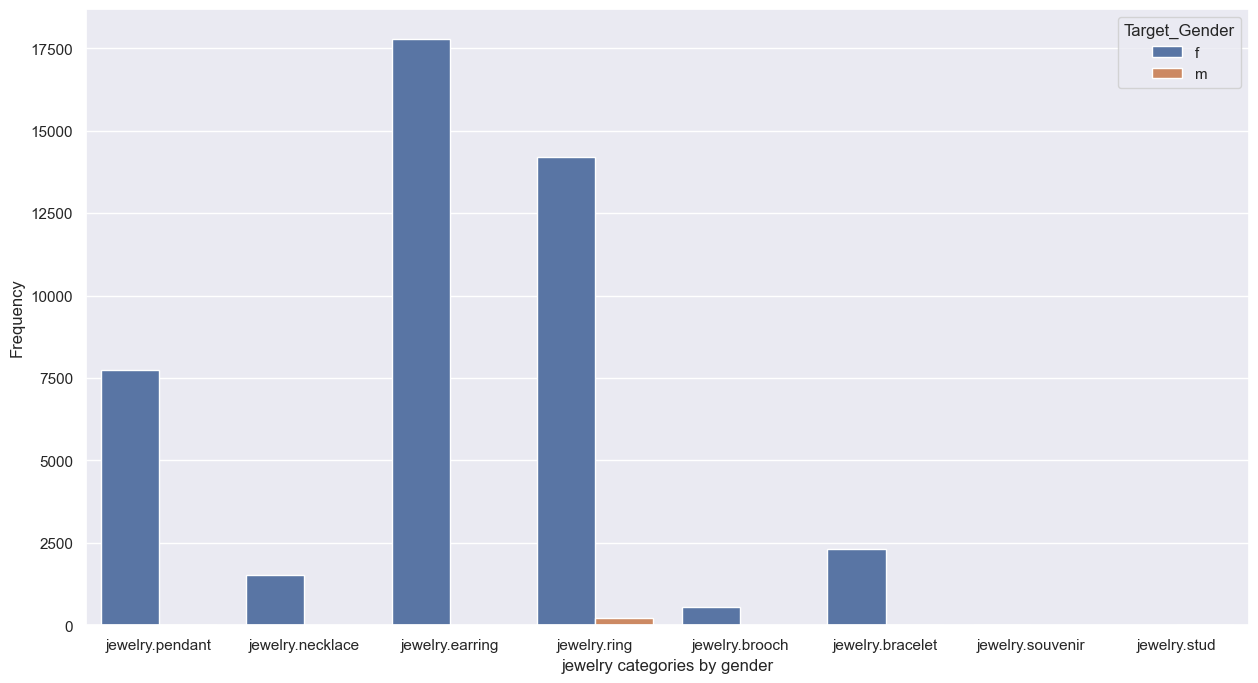

In [247]:
## Jewelry category by gender
plt.figure(figsize = (15, 8))

sns.countplot(data = real_categories, x = "Category", hue = "Target_Gender")

plt.xlabel("jewelry categories by gender")
plt.ylabel("Frequency")

plt.show(); plt.close()

In [248]:
## Gender skew in original data
df["Target_Gender"].value_counts(normalize = True)


Target_Gender
f    0.992376
m    0.007624
Name: proportion, dtype: float64

In [249]:
## Gender skew in original data
real_categories["Target_Gender"].value_counts(normalize = True)

Target_Gender
f    0.994434
m    0.005566
Name: proportion, dtype: float64

In [250]:
## feature correlation

In [251]:
## Encode Jewelry categories
encoded, category_code = pd.factorize(real_categories["Category"])
real_categories.loc[:, "Category"] = encoded


In [252]:
## Encode Jewelry Target GEnder
encoded, category_code = pd.factorize(real_categories["Target_Gender"])
real_categories.loc[:, "Target_Gender"] = encoded

In [253]:
## Encode Jewelry Main gem
encoded, category_code = pd.factorize(real_categories["Main_Gem"])
real_categories.loc[:, "Main_Gem"] = encoded

In [254]:
## Encode Jewelry Main color
encoded, category_code = pd.factorize(real_categories["Main_Color"])
real_categories.loc[:, "Main_Color"] = encoded

In [255]:
## Encode Jewelry metal
encoded, category_code = pd.factorize(real_categories["Main_metal"])
real_categories.loc[:, "Main_metal"] = encoded

In [256]:
real_categories.head(5)

,Order_Datetime,Order_ID,Product_ID,SKU_Quantity,Category_ID,Category,Brand_ID,Price_USD,User_ID,Target_Gender,Main_Color,Main_metal,Main_Gem
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,0,1.0,54.66,1.515916e+18,0,0,0,0
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,0,0.0,88.90,1.515916e+18,0,1,0,1
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,1,0.0,417.67,1.515916e+18,-1,1,0,2
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,2,1.0,102.27,1.515916e+18,-1,1,0,-1
5,2018-12-02 22:09:34 UTC,1925760595336888995,1600021442638905547,1,1.806829e+18,2,0.0,150.55,1.515916e+18,-1,1,0,1


In [257]:
real_categories.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80458 entries, 1 to 95909
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_Datetime  80458 non-null  object 
 1   Order_ID        80458 non-null  int64  
 2   Product_ID      80458 non-null  int64  
 3   SKU_Quantity    80458 non-null  int64  
 4   Category_ID     80458 non-null  float64
 5   Category        80458 non-null  object 
 6   Brand_ID        76991 non-null  float64
 7   Price_USD       80458 non-null  float64
 8   User_ID         80458 non-null  float64
 9   Target_Gender   80458 non-null  object 
 10  Main_Color      80458 non-null  object 
 11  Main_metal      80458 non-null  object 
 12  Main_Gem        80458 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 8.6+ MB


In [258]:
## feature correlation
correlation = real_categories.drop(labels = ["Order_Datetime", "User_ID", "Order_ID", "Product_ID"], axis =1).corr(method = "spearman")

In [259]:
correlation

,SKU_Quantity,Category_ID,Category,Brand_ID,Price_USD,Target_Gender,Main_Color,Main_metal,Main_Gem
SKU_Quantity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category_ID,NaN,1.000000,-0.886212,0.111328,-0.296495,0.106286,0.003396,0.157834,0.050483
Category,NaN,-0.886212,1.000000,-0.111680,0.267257,-0.124101,-0.059402,0.105056,-0.082944
Brand_ID,NaN,0.111328,-0.111680,1.000000,-0.018428,0.623701,0.100816,0.003835,0.076277
Price_USD,NaN,-0.296495,0.267257,-0.018428,1.000000,0.049532,0.013177,-0.173050,-0.006630
Target_Gender,NaN,0.106286,-0.124101,0.623701,0.049532,1.000000,0.056950,-0.046436,0.166125
Main_Color,NaN,0.003396,-0.059402,0.100816,0.013177,0.056950,1.000000,-0.238080,0.136232
Main_metal,NaN,0.157834,0.105056,0.003835,-0.173050,-0.046436,-0.238080,1.000000,-0.055603
Main_Gem,NaN,0.050483,-0.082944,0.076277,-0.006630,0.166125,0.136232,-0.055603,1.000000


In [260]:
correlation["Category"]

SKU_Quantity          NaN
Category_ID     -0.886212
Category         1.000000
Brand_ID        -0.111680
Price_USD        0.267257
Target_Gender   -0.124101
Main_Color      -0.059402
Main_metal       0.105056
Main_Gem        -0.082944
Name: Category, dtype: float64

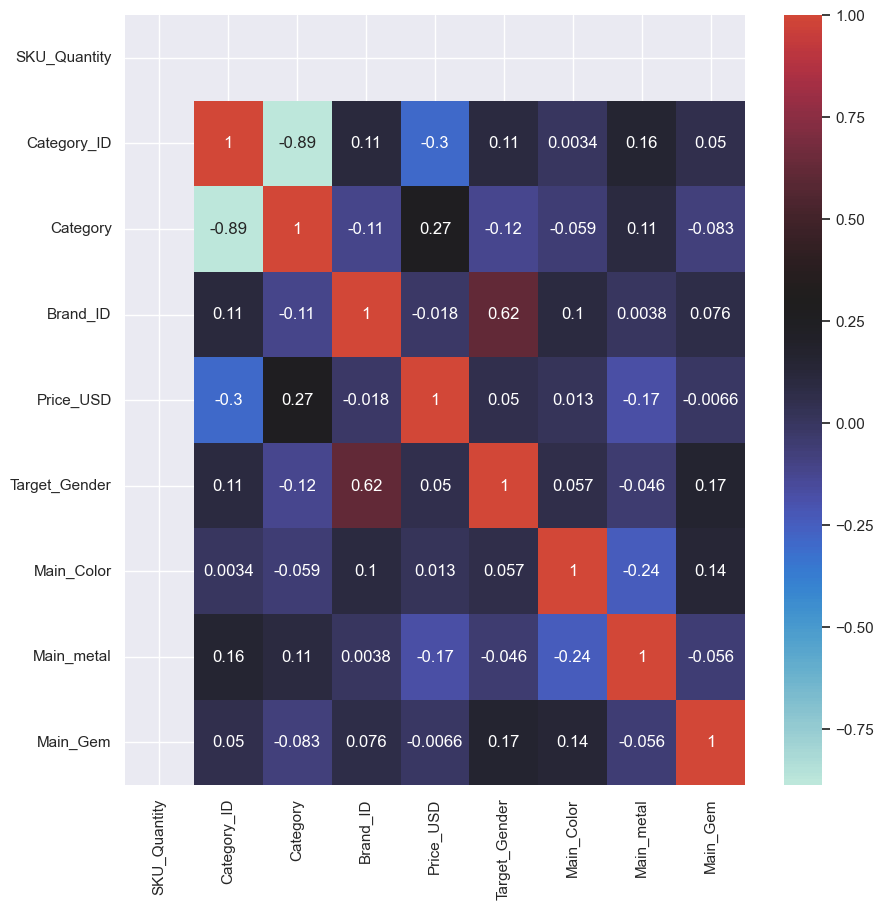

In [261]:
## correlation heatmap

plt.figure(figsize = (10,10))

sns.heatmap(correlation, annot = True, center = .3)

plt.show(); plt.close()

In [262]:
## set the correlation limit

upper = 1

lower = .2

In [263]:
## explicitly obtain correlated columns

correlated_columns = {
    column: correlation[(correlation[column] > lower) & (upper > correlation [column])].index.tolist()
    for column in correlation.columns
}

In [264]:
correlated_columns

{'SKU_Quantity': [],
 'Category_ID': [],
 'Category': ['Price_USD'],
 'Brand_ID': ['Target_Gender'],
 'Price_USD': ['Category'],
 'Target_Gender': ['Brand_ID'],
 'Main_Color': [],
 'Main_metal': [],
 'Main_Gem': []}

## Data Implication
implied by our findings above, we can say the following
- 1, Missing Values: There are a lot of missing values in the dataset, this can be fixed by either imputation or missingness encoding
- 2, Data Corruption: Variables like jewelry category contain corrupt values
- 3, Rare Values: Some features have values that occure rarely like The Target_Gender column where male is hardly represented. This can be a data issue or a true reflection of data distribution
- 4, Low cardinality/Feature Invariant: The SKU_Quantity has only one unique value. This provide no information
- 5, Target Skewer: The target variable is highly skewed right. This can represent an issue during training
- 6, Correlation: most of the features exhibit low multiculiniarity However the target variable low correlation with the independent variables

# Steps to prepare our data
- Eliminate unuseful features
- Extract records with actual category
- Encode categorical features if required
- Account for Target Skew
- Fix missing values

In [265]:
## columns to eliminate
columns_to_eliminate = [
    "SKU_Quantity",
    "User_ID",
    "Order_ID",
    "Product_ID",
    "Category_ID"
]

In [266]:
## Eliminate unuseful features
df.drop(labels = columns_to_eliminate, axis = 1, inplace=True)

In [267]:
#check
df.head(5)

,Order_Datetime,Category,Brand_ID,Price_USD,Target_Gender,Main_Color,Main_metal,Main_Gem
0,2018-12-01 17:38:31 UTC,NaN,NaN,212.14,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42 UTC,jewelry.pendant,1.0,54.66,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,jewelry.pendant,0.0,88.90,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,jewelry.necklace,0.0,417.67,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,jewelry.earring,1.0,102.27,NaN,red,gold,NaN


In [268]:
#drop Order_datetime aswell
df.drop(labels = ["Order_Datetime"], axis = 1, inplace=True)

In [269]:
## cehck
df.shape

(95910, 7)

In [270]:
## Eliminate the unrealistick category
df = df.loc[df["Category"].isin(categories), :]

In [271]:
from sklearn.model_selection import train_test_split

In [272]:
## seperate features from labels
x, y = df.drop(labels = ["Price_USD"], axis = 1), df["Price_USD"]

In [273]:
### create train and test splits
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = .1)

## Data Modeling
- Linear regression
- Extremely random forest (Extra trees)
- Adoptive Boosting (AdaBoost) &
- Catboost

In [274]:
## import 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.compose import TransformedTargetRegressor, ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import AdaBoostRegressor, ExtraTreesRegressor
from catboost import CatBoostRegressor

from sklearn.preprocessing import PowerTransformer


In [275]:
def generate_pipeline(model, column_indices, categorical_indices, fill_missing = True, one_hot = True, label_encode = False):
    
    #fix missing values
    first_transformer = ColumnTransformer(
        transformers = [
            ("imputer", SimpleImputer(strategy = "most_frequent"), column_indices)
        ],
        remainder = "passthrough",
        sparse_threshold = 0.
    )
    
    #Onehot encode
    second_transformer = ColumnTransformer(
        transformers = [
            ("one_hot", OneHotEncoder(handle_unknown="ignore"), categorical_indices)
        ],
        remainder = "passthrough",
        sparse_threshold = 0.
    )
    
    #label encode
    third_transformer = ColumnTransformer(
        transformers = [
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_indices)
        ],
        remainder = "passthrough", 
        sparse_threshold = 0.
    )
    
    steps = []
    
    if fill_missing:
        steps.append(("first", first_transformer))
        
    if label_encode:
        steps.append(("third", third_transformer))
        
    if one_hot:
        steps.append(("second", second_transformer))
        
    steps.append(("model", model))
        
    model_pipe = Pipeline(steps = steps)
    
    return model_pipe
        
    

In [276]:
x.head(5)

,Category,Brand_ID,Target_Gender,Main_Color,Main_metal,Main_Gem
1,jewelry.pendant,1.0,f,white,gold,sapphire
2,jewelry.pendant,0.0,f,red,gold,diamond
3,jewelry.necklace,0.0,NaN,red,gold,amethyst
4,jewelry.earring,1.0,NaN,red,gold,NaN
5,jewelry.earring,0.0,NaN,red,gold,diamond


In [277]:
# Generate indices
columns = x.columns.tolist()

columns_indices = [columns.index(c) for c in columns]
categorical_features = [c for c in columns if c not in ["Brand_ID"]]
categorical_indices = [columns.index(c) for c in categorical_features]

In [278]:
columns_indices

[0, 1, 2, 3, 4, 5]

In [279]:
categorical_indices

[0, 2, 3, 4, 5]

In [280]:
import mlflow
import mlflow.sklearn  # Use the relevant MLflow module for your model type
import os

In [281]:
## set tracking URI for MLflow

mlflow.set_tracking_uri("/Users/xlade/Desktop/Amdari/Internship/Jewelry Price Optimization")

In [282]:
#This function Trains the given model and logs parameters, metrics, and artifacts using MLflow. 
#This function is model-agnostic and works with any scikit-learn compatible regressor.


def train_and_log_model(model, model_name, x_train, y_train, x_test, y_test, columns_indices, categorical_indices, fill_missing=True, one_hot=True, label_encode=False):
    
    # Set up the MLflow experiment
    mlflow.set_experiment("Experiments")

    # Begin an MLflow run
    with mlflow.start_run(run_name=f"{model_name}_Run"):
        # Add tags
        mlflow.set_tag("user", "Benson")
        mlflow.set_tag("dataset", "Jewelry Price Optimization")
        mlflow.set_tag("model_name", model_name)

        # Log model parameters dynamically
        for param, value in model.get_params().items():
            mlflow.log_param(param, value)

        # Log pipeline parameters
        mlflow.log_param("fill_missing", fill_missing)
        mlflow.log_param("one_hot", one_hot)
        mlflow.log_param("label_encode", label_encode)

        # Create a pipeline dynamically
        pipeline = generate_pipeline(
            model,
            columns_indices,
            categorical_indices,
            fill_missing=fill_missing,
            one_hot=one_hot,
            label_encode=label_encode
        )
        # Apply a target transformer (Box-Cox)
        pipeline = TransformedTargetRegressor(
            regressor=pipeline,
            transformer=PowerTransformer(method="box-cox")
        )

        # Train the pipeline
        pipeline.fit(x_train, y_train)

        # Log metrics
        train_rmse = mean_squared_error(y_train, pipeline.predict(x_train), squared=False)
        test_rmse = mean_squared_error(y_test, pipeline.predict(x_test), squared=False)
        mlflow.log_metric("train_rmse", train_rmse)
        mlflow.log_metric("test_rmse", test_rmse)

        train_mae = mean_absolute_error(y_train, pipeline.predict(x_train))
        test_mae = mean_absolute_error(y_test, pipeline.predict(x_test))
        mlflow.log_metric("train_mae", train_mae)
        mlflow.log_metric("test_mae", test_mae)

        train_r2 = r2_score(y_train, pipeline.predict(x_train))
        test_r2 = r2_score(y_test, pipeline.predict(x_test))
        mlflow.log_metric("train_r2", train_r2)
        mlflow.log_metric("test_r2", test_r2)

        # Generate and log a residual plot
        artifact_dir = f"artifacts/{model_name}"
        os.makedirs(artifact_dir, exist_ok=True)
        residuals = y_test - pipeline.predict(x_test)
        plt.scatter(pipeline.predict(x_test), residuals)
        plt.axhline(y=0, color="red", linestyle="--")
        plt.xlabel("Predicted Values")
        plt.ylabel("Residuals")
        plt.title(f"Residual Plot for {model_name}")
        residual_plot_path = os.path.join(artifact_dir, "residual_plot.png")
        plt.savefig(residual_plot_path)
        mlflow.log_artifact(residual_plot_path)

        # Log the entire pipeline (including preprocessing steps)
        mlflow.sklearn.log_model(pipeline, artifact_path=f"models/{model_name}")

Traceback (most recent call last):
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 328, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 422, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1368, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1361, in _read_helper
    result = read_yaml(root, file_name)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/utils/file_utils.py", line 310, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does not exist.")
mlflow.e

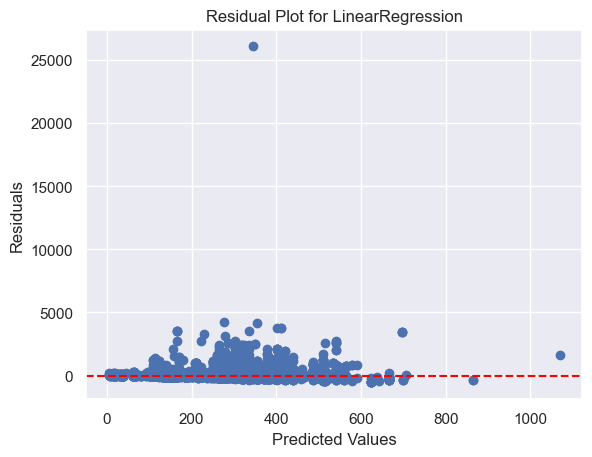

In [283]:
# Linear Regression
lr_model = LinearRegression()
train_and_log_model(lr_model, "LinearRegression", x_train, y_train, x_test, y_test, columns_indices, categorical_indices)


In [284]:
# AdaBoostRegressor
adaboost_model = AdaBoostRegressor(loss = "exponential", n_estimators=1000, learning_rate=0.1)
train_and_log_model(adaboost_model, "AdaBoostRegressor", x_train, y_train, x_test, y_test, columns_indices, categorical_indices)


Traceback (most recent call last):
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 328, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 422, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1368, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1361, in _read_helper
    result = read_yaml(root, file_name)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/utils/file_utils.py", line 310, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does not exist.")
mlflow.e

KeyboardInterrupt: 

Traceback (most recent call last):
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 328, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 422, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1368, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1361, in _read_helper
    result = read_yaml(root, file_name)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/utils/file_utils.py", line 310, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does not exist.")
mlflow.e

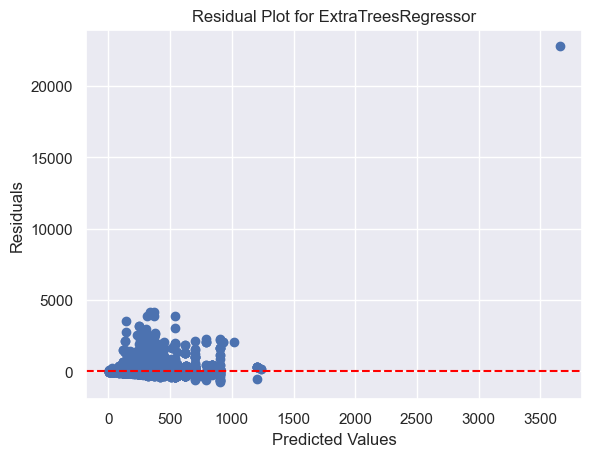

In [ ]:
#  ExtraTreesRegressor
extra_trees_model = ExtraTreesRegressor(criterion="friedman_mse", n_estimators=1000, bootstrap = True, max_depth=10)
train_and_log_model(extra_trees_model, "ExtraTreesRegressor", x_train, y_train, x_test, y_test, columns_indices, categorical_indices)

Traceback (most recent call last):
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 328, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 422, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1368, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/store/tracking/file_store.py", line 1361, in _read_helper
    result = read_yaml(root, file_name)
  File "/Users/xlade/Library/Python/3.9/lib/python/site-packages/mlflow/utils/file_utils.py", line 310, in read_yaml
    raise MissingConfigException(f"Yaml file '{file_path}' does not exist.")
mlflow.e

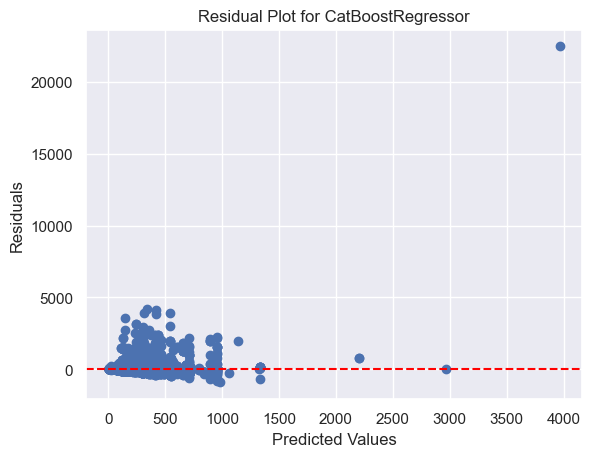

In [ ]:
# CatBoostRegressor
catboost_model = CatBoostRegressor(loss_function = "RMSE", iterations=10000, learning_rate=0.1, one_hot_max_size = 2, depth=6, verbose=0)
train_and_log_model(catboost_model, "CatBoostRegressor", x_train, y_train, x_test, y_test, columns_indices, categorical_indices)

## Model Deployment
- As observed from the model evaluation phase, although the CatBoost pipeline performed performed best among all models, its were still bad(R2 score = 0.32). A A report will be made to Germineye Emporium detailing tangible reasons and hypothesis for this.

- Recommendation will also be made

import mlflow
import mlflow.sklearn  # Use the relevant MLflow module for your model type